In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="threadpoolctl"
)

In [2]:
USE_HSV = True
USE_RGB = False
USE_GLCM = True

if USE_HSV and USE_RGB:
    raise ValueError(
        "HSV dan RGB tidak boleh digunakan bersamaan."
    )

if not (USE_HSV or USE_RGB):
    raise ValueError(
        "Pilih minimal HSV atau RGB."
    )

if not (USE_HSV or USE_RGB or USE_GLCM):
    raise ValueError(
        "Pilih minimal satu jenis fitur."
    )

feature_parts = []

if USE_HSV:
    feature_parts.append("hsv")

if USE_RGB:
    feature_parts.append("rgb")

if USE_GLCM:
    feature_parts.append("glcm")

FEATURES_NAME = "_".join(feature_parts)

In [3]:
df = pd.read_csv(f"features/{FEATURES_NAME}.csv")
df

,filename,label,H_Q1_B1,H_Q1_B2,H_Q1_B3,H_Q1_B4,H_Q1_B5,H_Q1_B6,H_Q1_B7,H_Q1_B8,...,correlation_d1_a90,correlation_d1_a135,correlation_d2_a0,correlation_d2_a45,correlation_d2_a90,correlation_d2_a135,correlation_d3_a0,correlation_d3_a45,correlation_d3_a90,correlation_d3_a135
0,100000_sample_ (1).jpg,100k,0.954896,0.291464,0.000162,0.000000,0.005173,0.016327,0.002182,0.054074,...,0.991089,0.979421,0.967998,0.979754,0.980559,0.979421,0.950121,0.954202,0.971901,0.953769
1,100000_sample_ (10).jpg,100k,0.999211,0.039604,0.000000,0.000000,0.000064,0.001910,0.000382,0.002038,...,0.990465,0.978796,0.968332,0.979177,0.981332,0.978796,0.951530,0.955657,0.973292,0.954916
2,100000_sample_ (11).jpg,100k,0.999645,0.025590,0.001457,0.004561,0.000633,0.000127,0.000063,0.005701,...,0.991861,0.980943,0.971543,0.982211,0.981542,0.980943,0.955597,0.958445,0.972042,0.956086
3,100000_sample_ (12).jpg,100k,0.995872,0.090479,0.000067,0.000000,0.000803,0.002208,0.000201,0.006826,...,0.991168,0.979711,0.968457,0.979057,0.982071,0.979711,0.951477,0.954519,0.973748,0.955960
4,100000_sample_ (13).jpg,100k,0.999583,0.025323,0.001914,0.004337,0.000000,0.000128,0.000765,0.013012,...,0.991997,0.981498,0.971684,0.982448,0.981522,0.981498,0.955160,0.958117,0.971849,0.956316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,5000_sample_ (5).jpg,5k,0.987665,0.015328,0.006590,0.028435,0.015772,0.003332,0.003925,0.152171,...,0.985693,0.975401,0.966285,0.975652,0.972590,0.975401,0.949572,0.949939,0.963089,0.949755
188,5000_sample_ (6).jpg,5k,0.998877,0.026134,0.003389,0.000000,0.000000,0.000000,0.000000,0.039363,...,0.982250,0.973181,0.972134,0.973603,0.961062,0.973181,0.961071,0.945565,0.943196,0.944681
189,5000_sample_ (7).jpg,5k,0.984570,0.019591,0.017361,0.037032,0.153384,0.019671,0.005176,0.068011,...,0.975815,0.965259,0.964907,0.964756,0.947843,0.965259,0.949406,0.926096,0.923263,0.929821
190,5000_sample_ (8).jpg,5k,0.999774,0.019035,0.008383,0.004286,0.000000,0.000189,0.000693,0.000315,...,0.982877,0.967066,0.952386,0.967680,0.965136,0.967066,0.928450,0.933169,0.950444,0.930465


In [4]:
x = df.drop(columns=["filename", "label"])
y = df["label"]

In [5]:
x

,H_Q1_B1,H_Q1_B2,H_Q1_B3,H_Q1_B4,H_Q1_B5,H_Q1_B6,H_Q1_B7,H_Q1_B8,S_Q1_B1,S_Q1_B2,...,correlation_d1_a90,correlation_d1_a135,correlation_d2_a0,correlation_d2_a45,correlation_d2_a90,correlation_d2_a135,correlation_d3_a0,correlation_d3_a45,correlation_d3_a90,correlation_d3_a135
0,0.954896,0.291464,0.000162,0.000000,0.005173,0.016327,0.002182,0.054074,0.993129,0.115075,...,0.991089,0.979421,0.967998,0.979754,0.980559,0.979421,0.950121,0.954202,0.971901,0.953769
1,0.999211,0.039604,0.000000,0.000000,0.000064,0.001910,0.000382,0.002038,0.922410,0.375590,...,0.990465,0.978796,0.968332,0.979177,0.981332,0.978796,0.951530,0.955657,0.973292,0.954916
2,0.999645,0.025590,0.001457,0.004561,0.000633,0.000127,0.000063,0.005701,0.973550,0.209002,...,0.991861,0.980943,0.971543,0.982211,0.981542,0.980943,0.955597,0.958445,0.972042,0.956086
3,0.995872,0.090479,0.000067,0.000000,0.000803,0.002208,0.000201,0.006826,0.918539,0.393328,...,0.991168,0.979711,0.968457,0.979057,0.982071,0.979711,0.951477,0.954519,0.973748,0.955960
4,0.999583,0.025323,0.001914,0.004337,0.000000,0.000128,0.000765,0.013012,0.974637,0.205699,...,0.991997,0.981498,0.971684,0.982448,0.981522,0.981498,0.955160,0.958117,0.971849,0.956316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,0.987665,0.015328,0.006590,0.028435,0.015772,0.003332,0.003925,0.152171,0.970383,0.129670,...,0.985693,0.975401,0.966285,0.975652,0.972590,0.975401,0.949572,0.949939,0.963089,0.949755
188,0.998877,0.026134,0.003389,0.000000,0.000000,0.000000,0.000000,0.039363,0.922511,0.361454,...,0.982250,0.973181,0.972134,0.973603,0.961062,0.973181,0.961071,0.945565,0.943196,0.944681
189,0.984570,0.019591,0.017361,0.037032,0.153384,0.019671,0.005176,0.068011,0.985376,0.092565,...,0.975815,0.965259,0.964907,0.964756,0.947843,0.965259,0.949406,0.926096,0.923263,0.929821
190,0.999774,0.019035,0.008383,0.004286,0.000000,0.000189,0.000693,0.000315,0.988981,0.077311,...,0.982877,0.967066,0.952386,0.967680,0.965136,0.967066,0.928450,0.933169,0.950444,0.930465


In [6]:
y

0      100k
1      100k
2      100k
3      100k
4      100k
       ... 
187      5k
188      5k
189      5k
190      5k
191      5k
Name: label, Length: 192, dtype: str

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("="*40)
print("Train :", x_train.shape)
print("Test  :", x_test.shape)
print("="*40)

Train : (153, 144)
Test  : (39, 144)


In [8]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
joblib.dump(scaler,f"models/knn/{FEATURES_NAME}_scaler.pkl")

['models/knn/hsv_glcm_scaler.pkl']

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
joblib.dump(knn, f"models/knn/{FEATURES_NAME}_model.pkl")

['models/knn/hsv_glcm_model.pkl']

In [12]:
# Prediksi data train
y_train_pred = knn.predict(x_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(x_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.8954248366013072
Testing Accuracy  : 0.9230769230769231

Classification Report:

              precision    recall  f1-score   support

        100k       1.00      1.00      1.00         6
         10k       0.75      1.00      0.86         6
         20k       1.00      0.86      0.92         7
          2k       1.00      0.86      0.92         7
         50k       1.00      1.00      1.00         7
          5k       0.83      0.83      0.83         6

    accuracy                           0.92        39
   macro avg       0.93      0.92      0.92        39
weighted avg       0.94      0.92      0.92        39



In [13]:
# Cross Validation KNN
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_scores = cross_val_score(
    knn, 
    x_train_scaled, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("KNN Cross Validation Scores:")
print(f"Scores per fold: {knn_cv_scores}")
print(f"Mean CV Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {knn_cv_scores.std():.4f}")

KNN Cross Validation Scores:
Scores per fold: [0.67741935 0.83870968 0.80645161 0.9        0.76666667]
Mean CV Accuracy: 0.7978
Std CV Accuracy: 0.0744


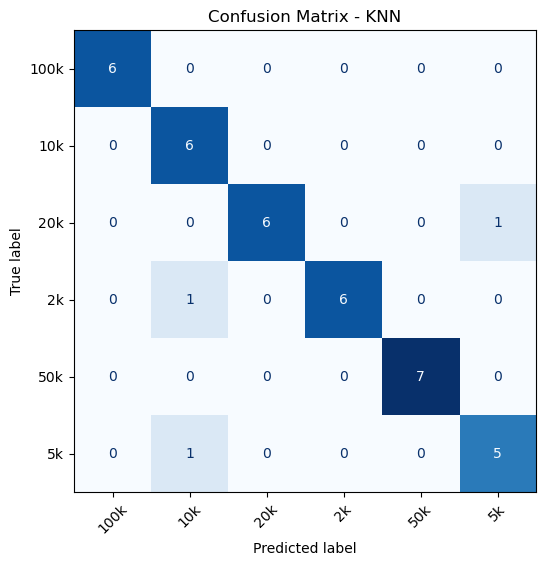

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - KNN")
plt.show()

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
joblib.dump(rf, f"models/rf/{FEATURES_NAME}_model.pkl")

['models/rf/hsv_glcm_model.pkl']

In [17]:
y_train_pred_2 = rf.predict(x_train)
y_test_pred_2 = rf.predict(x_test)

train_acc_rf = accuracy_score(
    y_train,
    y_train_pred_2
)

test_acc_rf = accuracy_score(
    y_test,
    y_test_pred_2
)

print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy :", test_acc_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_2))

Training Accuracy: 1.0
Testing Accuracy : 0.8974358974358975

Classification Report:

              precision    recall  f1-score   support

        100k       1.00      1.00      1.00         6
         10k       0.83      0.83      0.83         6
         20k       1.00      0.71      0.83         7
          2k       1.00      0.86      0.92         7
         50k       1.00      1.00      1.00         7
          5k       0.67      1.00      0.80         6

    accuracy                           0.90        39
   macro avg       0.92      0.90      0.90        39
weighted avg       0.92      0.90      0.90        39



In [18]:
# Cross Validation MLP
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    rf, 
    x_train, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("RF Cross Validation Scores:")
print(f"Scores per fold: {rf_cv_scores}")
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {rf_cv_scores.std():.4f}")

RF Cross Validation Scores:
Scores per fold: [0.87096774 0.93548387 1.         0.96666667 0.93333333]
Mean CV Accuracy: 0.9413
Std CV Accuracy: 0.0427


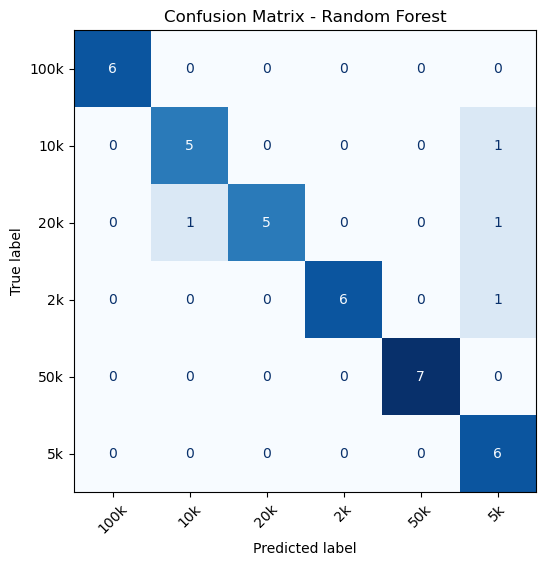

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(
    y_test,
    y_test_pred_2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Random Forest")
plt.show()